# GA_24_11 scWGS - Downsample 40M stats
Downsampled to 40M read pairs and mapped to reference

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import seaborn as sns
import seaborn.objects as so
import statsmodels.api as sm

custom_params = {
    "axes.spines.right": False, 
    "axes.spines.top": False,
    "axes.edgecolor": "black",
}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../../figures/svg")

## Functions

In [2]:
def interpolate(y):
    x = np.linspace(0, 1, len(y))
    ynew = np.interp(0.5, x, y.values)
    return ynew

def lowess(y, frac=0.1):
    # Lowess smoothing
    x = np.linspace(0, 1, len(y))
    lowess = sm.nonparametric.lowess(y, x, frac=frac)
    return lowess[:,1]

def mad(x):
    # Median absolute deviation
    return np.abs(x - x.median()).median()

def mapd(data, cov_col="cov"):
    # Median absolute pairwise deviation
    dev = []

    # Find binsize
    binsize = data.iloc[0,:]["end"] - data.iloc[0,:]["start"]
    for c, cdata in data.groupby("contig"):
        x = cdata["cov"].values

        # Calculate deviation between adjacent bins
        deviation = x[:-1] - x[1:]

        # Find gaps
        gaps = (cdata["start"].values[1:] - cdata["start"].values[:-1]) > binsize
        # Remove gaps
        deviation = deviation[~gaps]
        dev.append(deviation)

    # Calculate median absolute pairwise deviation
    return np.median(np.abs(np.concatenate(dev)))



## Sample info

In [3]:
chr1toX = ["chr1", "chr2", "chr3", "chr4", "chr5", "chr6", "chr7", "chr8", "chr9", "chr10", "chr11", "chr12", "chr13", "chr14", "chr15", "chr16", "chr17", "chr18", "chr19", "chr20", "chr21", "chr22", "chrX"]

base_path = Path("../../analysis/downsample_40M/downstream")

samples = pd.read_csv("../../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")
human_samples


,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,P33410_1001,Q_B2_cell_01,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#01),Single cell
1,P33410_1002,Q_C2_cell_02,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#02),Single cell
2,P33410_1003,Q_D2_cell_03,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#03),Single cell
3,P33410_1004,Q_E2_cell_04,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#04),Single cell
4,P33410_1005,Q_F2_cell_05,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#05),Single cell
5,P33410_1006,Q_G2_cell_06,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#06),Single cell
7,P33410_1008,Q_A3_cell_07,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#07),Single cell
8,P33410_1009,Q_B3_cell_08,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#08),Single cell
9,P33410_1010,Q_C3_cell_09,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#09),Single cell
10,P33410_1011,Q_D3_cell_10,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#10),Single cell


## Coverage evenness
### MAPD / MAD
Use 100kb binned coverage to measure evenness using metrics:
- Median absolute deviation (MAD)
- Median pairwise absolute deviation (MAPD)


In [4]:

chr1toX = ["chr1", "chr2", "chr3", "chr4", "chr5", "chr6", "chr7", "chr8", "chr9", "chr10", "chr11", "chr12", "chr13", "chr14", "chr15", "chr16", "chr17", "chr18", "chr19", "chr20", "chr21", "chr22", "chrX"]
cov = []
for i, sample in human_samples.iterrows():
    path = base_path / f"mosdepth_100kb/{sample["NGI ID"]}.regions.bed.gz"
    d = pd.read_csv(path, sep="\t", header=None, names=["contig", "start", "end", "cov"])
    d = d[d["contig"].isin(chr1toX)]

    cov.append({
        "Sample": sample["User ID"],
        "Kit": sample["Kit"],
        "IsSingleCell": sample["IsSingleCell"],
        "Type": sample["Type"],
        "mean_cov": d["cov"].mean(),
        "std_cov": d["cov"].std(),
        "cv_cov": d["cov"].std() / d["cov"].mean(),
        "zero_cov": (d["cov"] == 0).sum() / len(d["cov"]),
        "mad": mad(d["cov"]),
        "mapd": mapd(d)
    })

cov = pd.DataFrame(cov)
cov.head()

,Sample,Kit,IsSingleCell,Type,mean_cov,std_cov,cv_cov,zero_cov,mad,mapd
0,Q_B2_cell_01,MDA/REPLI-g,True,Single cell,3.535356,3.120860,0.882757,0.041127,1.59108,1.509075
1,Q_C2_cell_02,MDA/REPLI-g,True,Single cell,3.540234,3.316971,0.936935,0.040500,1.66946,1.535995
2,Q_D2_cell_03,MDA/REPLI-g,True,Single cell,3.524724,3.812926,1.081766,0.041588,1.80533,1.473055
3,Q_E2_cell_04,MDA/REPLI-g,True,Single cell,3.501618,3.147978,0.899007,0.041588,1.56761,1.515775
4,Q_F2_cell_05,MDA/REPLI-g,True,Single cell,3.523676,3.385601,0.960815,0.040434,1.66686,1.512430


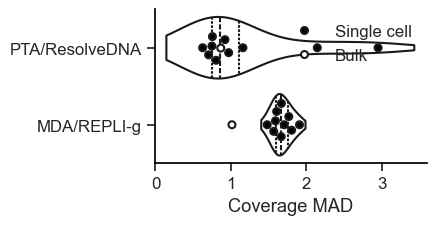

In [5]:
def plot_cov_h(cov, x, xlabel, filename=None):
    fig, ax = plt.subplots(figsize=(3.5, 2))
    ax = sns.violinplot(
        cov.query("Type == 'Single cell'"),
        x=x, 
        y="Kit",
        order=["PTA/ResolveDNA", "MDA/REPLI-g"],
        inner="quart", 
        fill=None, 
        legend=False,
        color="k",
        density_norm="width", 
        cut=1,
        ax=ax
    )
    ax = sns.swarmplot(
        cov, 
        x=x, 
        y="Kit", 
        order=["PTA/ResolveDNA", "MDA/REPLI-g"],
        hue="Type",
        hue_order=["Single cell", "Bulk"],
        palette=["black", "white"],
        edgecolor="k",
        size=5,
        linewidth=1.5,

    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.set_xlim(left=0)
    plt.legend(frameon=False, loc="upper right")
    if filename:
        plt.savefig(figdir / filename, bbox_inches="tight")

plot_cov_h(cov, "mad", "Coverage MAD", "coverage_evenness_mad_h.svg")


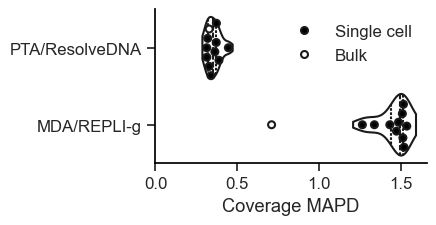

In [6]:
plot_cov_h(cov, "mapd", "Coverage MAPD", "coverage_evenness_mapd_h.svg")

In [7]:

chr1toX = ["chr1", "chr2", "chr3", "chr4", "chr5", "chr6", "chr7", "chr8", "chr9", "chr10", "chr11", "chr12", "chr13", "chr14", "chr15", "chr16", "chr17", "chr18", "chr19", "chr20", "chr21", "chr22", "chrX"]
pdev = []
for i, sample in human_samples.iterrows():
    path = base_path / f"mosdepth_100kb/{sample["NGI ID"]}.regions.bed.gz"
    d = pd.read_csv(path, sep="\t", header=None, names=["contig", "start", "end", "cov"])
    d = d.query("contig in @chr1toX")

    dev = []

    # Find binsize
    binsize = d.iloc[0,:]["end"] - d.iloc[0,:]["start"]
    for c, cdata in d.groupby("contig"):
        x = cdata["cov"].values

        # Calculate deviation between adjacent bins
        deviation = x[:-1] - x[1:]

        # Find gaps
        gaps = (cdata["start"].values[1:] - cdata["start"].values[:-1]) > binsize
        # Remove gaps
        deviation = deviation[~gaps]
        dev.append(deviation)

    dev = np.abs(np.concatenate(dev))
    samples_ids = np.repeat(sample["User ID"], len(dev))
    pdev.append(pd.DataFrame({
        "User ID": list(samples_ids),
        "dev": list(dev)
    }))

pdev = pd.concat(pdev, ignore_index=True)
pdev = pdev.merge(human_samples, left_on="User ID", right_on="User ID")
pdev.head()

,User ID,dev,NGI ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,Q_B2_cell_01,5.94845,P33410_1001,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#01),Single cell
1,Q_B2_cell_01,0.29096,P33410_1001,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#01),Single cell
2,Q_B2_cell_01,1.16243,P33410_1001,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#01),Single cell
3,Q_B2_cell_01,0.02883,P33410_1001,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#01),Single cell
4,Q_B2_cell_01,0.31269,P33410_1001,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#01),Single cell


(0.0, 40.0)

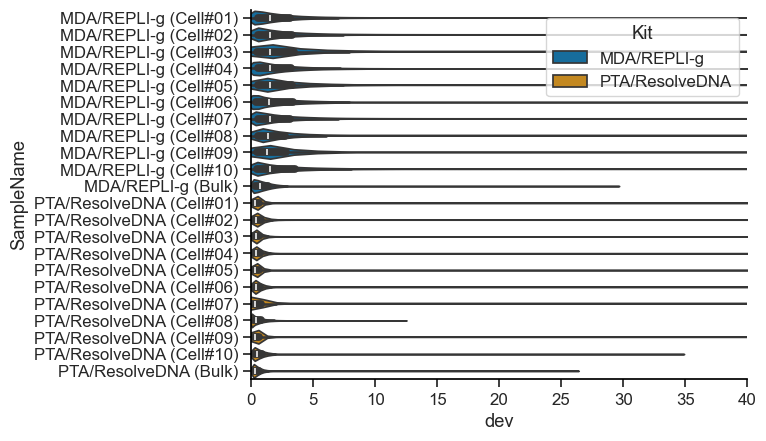

In [8]:
ax = sns.violinplot(pdev, x="dev", y="SampleName", hue="Kit", density_norm="width", cut=1)
ax.set_xlim(0,40)

### Re-binned coverage

In [9]:
bin_sizes =[
    100_000, # current
    200_000,
    300_000,
    400_000,
    500_000,
    1_000_000,
    2_500_000,
    5_000_000,
    10_000_000,
]
cov = []

for i, sample in human_samples.iterrows():
    path = base_path / f"mosdepth_100kb/{sample["NGI ID"]}.regions.bed.gz"
    d_base = pd.read_csv(path, sep="\t", header=None, names=["contig", "start", "end", "cov"], nrows=1e6)
    d_base = d_base[d_base["contig"].isin(chr1toX)].copy()
    d_base["len"] = d_base["end"] - d_base["start"]
    d_base["bases"] = d_base["len"] * d_base["cov"]
    
    base_binsize = d_base["len"].mode().values[0]
    
    for binsize in bin_sizes:
        print("bin size=", binsize, end=" ")
        d = d_base.copy()

        d["bin"] = (d["start"] // binsize) * binsize
        d["count"] = d["bin"]
        d = d.groupby(["contig", "bin"]).agg(
            {"bases": "sum", "count": "count", "len": "sum", "start": "min", "end": "max"}).reset_index()
        
        d["cov"] = d["bases"] / d["len"]
        
        mapd_unfiltered = mapd(d, cov_col="cov")

        # Filter out bins with uncovered sub-bins
        d = d[d["count"] == binsize // 100_000]
        mapd_filtered = mapd(d, cov_col="cov")
    
        cov.append({
            "NGI ID": sample["NGI ID"],
            "Sample": sample["User ID"],
            "Kit": sample["Kit"],
            "Type": sample["Type"],
            "mapd": mapd_unfiltered,
            "mapd_filtered": mapd_filtered,
            "binsize": binsize
        })
    
cov = pd.DataFrame(cov)
cov

bin size= 100000 bin size= 200000 bin size= 300000 bin size= 400000 bin size= 500000 bin size= 1000000 bin size= 2500000 bin size= 5000000 bin size= 10000000 bin size= 100000 bin size= 200000 bin size= 300000 bin size= 400000 bin size= 500000 bin size= 1000000 bin size= 2500000 bin size= 5000000 bin size= 10000000 bin size= 100000 bin size= 200000 bin size= 300000 bin size= 400000 bin size= 500000 bin size= 1000000 bin size= 2500000 bin size= 5000000 bin size= 10000000 bin size= 100000 bin size= 200000 bin size= 300000 bin size= 400000 bin size= 500000 bin size= 1000000 bin size= 2500000 bin size= 5000000 bin size= 10000000 bin size= 100000 bin size= 200000 bin size= 300000 bin size= 400000 bin size= 500000 bin size= 1000000 bin size= 2500000 bin size= 5000000 bin size= 10000000 bin size= 100000 bin size= 200000 bin size= 300000 bin size= 400000 bin size= 500000 bin size= 1000000 bin size= 2500000 bin size= 5000000 bin size= 10000000 bin size= 100000 bin size= 200000 bin size= 300000 b

,NGI ID,Sample,Kit,Type,mapd,mapd_filtered,binsize
0,P33410_1001,Q_B2_cell_01,MDA/REPLI-g,Single cell,1.509075,1.509075,100000
1,P33410_1001,Q_B2_cell_01,MDA/REPLI-g,Single cell,1.433370,1.432380,200000
2,P33410_1001,Q_B2_cell_01,MDA/REPLI-g,Single cell,1.309002,1.307613,300000
3,P33410_1001,Q_B2_cell_01,MDA/REPLI-g,Single cell,1.199582,1.198661,400000
4,P33410_1001,Q_B2_cell_01,MDA/REPLI-g,Single cell,1.124773,1.124612,500000
...,...,...,...,...,...,...,...
193,P33410_1024,B_H3_10_cells,PTA/ResolveDNA,Bulk,0.327328,0.326770,500000
194,P33410_1024,B_H3_10_cells,PTA/ResolveDNA,Bulk,0.355895,0.354872,1000000
195,P33410_1024,B_H3_10_cells,PTA/ResolveDNA,Bulk,0.395802,0.391318,2500000
196,P33410_1024,B_H3_10_cells,PTA/ResolveDNA,Bulk,0.420369,0.408509,5000000


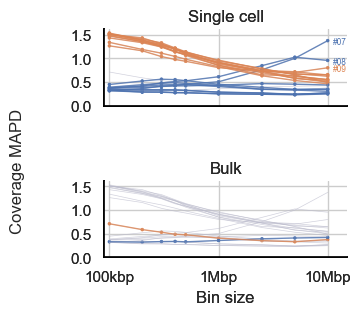

In [10]:
def format_bases(x):
    if x < 1e3:
        return f"{x:.0f}bp"
    if x < 1e6:
        return f"{x / 1e3:.0f}kbp"
    if x < 1e9:
        return f"{x / 1e6:.0f}Mbp"
    return f"{x / 1e9:.0f}Gbp"

d = cov.copy()
d["Cell"] = "#" + d["Sample"].str.split("_").str[-1]
# Remove for bulk samples
d["Cell"] = d["Cell"].str.replace("#cells", "")
fig = plt.figure(figsize=(3.5, 4))
fig.text(0.0, 0.5, "Coverage MAPD", ha="center", va="center", rotation=90, fontsize=12)
p = (
    so.Plot(data=d, x="binsize", y="mapd_filtered", color="Kit")
    .facet(row="Type")
    .add(so.Lines(color="#bbca", linewidth=0.5), col=None, row=None, group="NGI ID", legend=False)
    .add(so.Lines(linewidth=1, alpha=0.8), color="Kit", group="NGI ID", legend=False)
    .add(so.Dot(pointsize=2), group="NGI ID", legend=False)
    
    
    .add(so.Text(halign="left", fontsize=6), data=d.query("binsize == binsize.max() & mapd_filtered > 0.7"), text="Cell")
    .limit(x=(min(bin_sizes)*0.9, max(bin_sizes)*1.5), y=(0, d["mapd_filtered"].max() * 1.05))
    .scale(
        x = so.Continuous(trans="log").label(mpl.ticker.FuncFormatter(lambda x, _: format_bases(x))),
        color = so.Nominal(order=["PTA/ResolveDNA", "MDA/REPLI-g"]),
        y=so.Continuous().tick(every=0.5)
    )
    .label(x="Bin size", y="")
    .layout(engine="tight", size=(3.5, 4))
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)   
    .on(fig)
    .save(figdir / "coverage_evenness_mapd_binsize.svg", dpi=300, bbox_inches="tight", transparent=True)
)

p.show()

### Lorenz curve

In [11]:
# Plot lorentz curve for coverage

covb = []
for i, sample in human_samples.iterrows():
    path = base_path / f"mosdepth_100kb/{sample["NGI ID"]}.regions.bed.gz"
    d = pd.read_csv(path, sep="\t", header=None, names=["contig", "start", "end", "cov"])
    d = d[d["contig"].isin(chr1toX)]
    d["Sample"] = sample["User ID"]
    d["Kit"] = sample["Kit"]
    d["IsSingleCell"] = sample["IsSingleCell"]
    d["Type"] = sample["Type"]

    covb.append(d)

covb = pd.concat(covb)
covb

,contig,start,end,cov,Sample,Kit,IsSingleCell,Type
0,chr1,0,100000,6.82822,Q_B2_cell_01,MDA/REPLI-g,True,Single cell
1,chr1,100000,200000,0.87977,Q_B2_cell_01,MDA/REPLI-g,True,Single cell
2,chr1,200000,300000,1.17073,Q_B2_cell_01,MDA/REPLI-g,True,Single cell
3,chr1,300000,400000,0.00830,Q_B2_cell_01,MDA/REPLI-g,True,Single cell
4,chr1,400000,500000,0.03713,Q_B2_cell_01,MDA/REPLI-g,True,Single cell
...,...,...,...,...,...,...,...,...
30316,chrX,155600000,155700000,3.49852,B_H3_10_cells,PTA/ResolveDNA,False,Bulk
30317,chrX,155700000,155800000,3.02252,B_H3_10_cells,PTA/ResolveDNA,False,Bulk
30318,chrX,155800000,155900000,3.40733,B_H3_10_cells,PTA/ResolveDNA,False,Bulk
30319,chrX,155900000,156000000,5.07762,B_H3_10_cells,PTA/ResolveDNA,False,Bulk


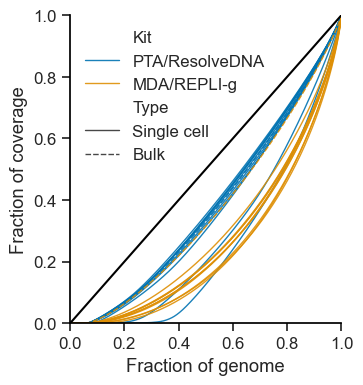

In [12]:
d = covb.sort_values("cov")
d["cum_cov"] = d.groupby("Sample")["cov"].transform(lambda x: x.cumsum() / x.sum())
d["rank"] = d.groupby("Sample")["cov"].transform(lambda x: x.rank(method="first"))
d["rank"] = d.groupby("Sample")["rank"].transform(lambda x: x / x.max())
d = d.sort_values("Sample")

fig, ax = plt.subplots(figsize=(3.5, 4))
ax = sns.lineplot(
    data=d, 
    x="rank", 
    y="cum_cov", 
    hue="Kit", 
    style="Type", 
    units="Sample", 
    estimator=None,
    alpha=0.9,
    lw=1,
)
ax.set_xlabel("Fraction of genome")
ax.set_ylabel("Fraction of coverage")
ax.axline((0, 0), slope=1, color="black")
plt.legend(frameon=False, loc="upper left")

ax.set_ylim(0, 1)
ax.set_xlim(0, 1)

plt.savefig(figdir / "coverage_lorentz_curve.svg", bbox_inches="tight")

## Coverage along genome

In [13]:
def get_100kb_bin(tsv, name):
    d = pd.read_csv(
        tsv, 
        sep="\t", 
        header=None, names=["contig", "start", "end", "cov"]
    )
    d = d[d["contig"].isin(chr1toX)]
    d["len"] = d["end"] - d["start"]
    d["bases"] = d["len"] * d["cov"]

    # Calculate coverage in 100kb bins
    binsize = 100_000
    d["bin"] = (d["start"] // binsize).astype(int)
    d = d.groupby(["contig", "bin"]).agg(
        {"bases": "sum", "len": "sum"}
    ).reset_index()
    d["start"] = d["bin"] * binsize
    d["end"] = d["start"] + binsize 
    d["cov"] = d["bases"] / d["len"]
    d = d.drop(["bin", "bases", "len"], axis=1)
    d["Sample"] = name
    return d

bcov = []

# Get 100kb bins for PacBio HiFi
dpb = get_100kb_bin("../../resources/PacBioHiFi_pr_023_003_MM1S_hificnv/MM1S.pr_023_003.depth.bedGraph", "PacBio HiFi")
bcov.append(dpb)

for i, sample in human_samples.iterrows():
    path = base_path / f"mosdepth_100kb/{sample["NGI ID"]}.regions.bed.gz"
    d = pd.read_csv(
        path, 
        sep="\t", 
        header=None, 
        names=["contig", "start", "end", "cov"]
    )
    d = d[d["contig"].isin(chr1toX)]
    if sample["IsSingleCell"]:
        d["Sample"] = f'{sample["Kit"]} (Cell #{sample["User ID"][-2:]})'
    else:  
        d["Sample"] = f'{sample["Kit"]} (Bulk)'
    d["Kit"] = sample["Kit"]
    d["IsSingleCell"] = sample["IsSingleCell"]
    bcov.append(d)

bcov = pd.concat(bcov).reset_index(drop=True)
bcov = bcov.pivot(index=["contig", "start", "end"], columns="Sample", values="cov")
# Remove rows with NaNs
bcov = bcov.dropna()

# Remove rows with any zeros
bcov = bcov[(bcov > 0).all(axis=1)]

bcov

Sample                      MDA/REPLI-g (Bulk)  MDA/REPLI-g (Cell #01)  \
contig start     end                                                     
chr1   0         100000                3.07249                 6.82822   
       100000    200000                0.97113                 0.87977   
       200000    300000                0.83427                 1.17073   
       400000    500000                0.08888                 0.03713   
       500000    600000                0.30104                 0.34982   
...                                        ...                     ...   
chrX   155400000 155500000             1.57789                 2.08309   
       155500000 155600000             2.73219                 6.34136   
       155600000 155700000             2.88838                10.61988   
       155800000 155900000             2.57347                 3.14004   
       155900000 156000000             2.79538                 1.90621   

Sample                      MDA/REPLI-g (Cell #02)  MDA/REPLI-g (Cell #03)  \
contig start     end                                                         
chr1   0         100000                    3.48769                 2.87332   
       100000    200000                    1.19144                 0.57686   
       200000    300000                    0.89635                 0.12704   
       400000    500000                    0.02191                 0.08136   
       500000    600000                    1.29358                 0.14104   
...                                            ...                     ...   
chrX   155400000 155500000                 0.34893                 4.62651   
       155500000 155600000                 1.44507                 9.61575   
       155600000 155700000                11.91403                 5.91827   
       155800000 155900000                 2.13764                 5.64451   
       155900000 156000000                 2.33261                11.73527   

Sample                      MDA/REPLI-g (Cell #04)  MDA/REPLI-g (Cell #05)  \
contig start     end                                                         
chr1   0         100000                    2.76705                 4.02358   
       100000    200000                    1.40190                 1.80658   
       200000    300000                    0.74675                 0.35137   
       400000    500000                    0.05134                 0.07545   
       500000    600000                    0.30775                 0.18296   
...                                            ...                     ...   
chrX   155400000 155500000                 0.58616                 0.59835   
       155500000 155600000                 1.50239                 4.54035   
       155600000 155700000                 2.05721                 5.42852   
       155800000 155900000                 5.38537                 4.54130   
       155900000 156000000                 2.44572                 4.09454   

Sample                      MDA/REPLI-g (Cell #06)  MDA/REPLI-g (Cell #07)  \
contig start     end                                                         
chr1   0         100000                    1.58748                 3.58463   
       100000    200000                    0.39885                 1.29646   
       200000    300000                    0.72749                 0.81516   
       400000    500000                    0.03278                 0.05584   
       500000    600000                    0.07204                 0.12367   
...                                            ...                     ...   
chrX   155400000 155500000                 0.00899                 1.64795   
       155500000 155600000                 0.00556                 0.90612   
       155600000 155700000                 0.01167                 3.78875   
       155800000 155900000                 0.02879                 0.26157   
       155900000 156000000                 0.07681                 0.45

### Pairwise correlation

In [14]:
def plot_hexbin(x, y, data, xmax=None, ymax=None, ax=None, **kwargs):
    if not ax:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure
    xd = data[x]
    yd = data[y]

    # Normalize to median
    xd = 2 * xd / xd.median()
    yd = 2 * yd / yd.median()

    ymax = xd.quantile(0.999) if not ymax else ymax
    xmax = yd.quantile(0.999) if not xmax else xmax

    mask = (xd < xmax) & (yd < ymax)
    xd = xd[mask]
    yd = yd[mask]
    hb = ax.hexbin(xd, yd, gridsize=100, cmap='viridis', bins='log', mincnt=None, **kwargs)
    pearson = data[x].corr(data[y], method="pearson")

    cb = fig.colorbar(hb, ax=ax, label='count')
    ax.set_xlabel(f"Copy number ({x})")
    ax.set_ylabel(f"Copy number ({y})")
    ax.set_title(f"{x} vs {y} (r = {pearson:.2f})")
    ax.set_xlim(right=xmax)
    ax.set_ylim(top=ymax)

    plt.show()

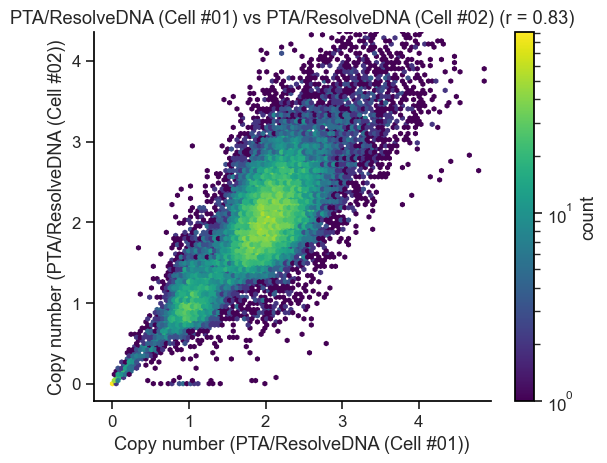

In [15]:
plot_hexbin("PTA/ResolveDNA (Cell #01)", "PTA/ResolveDNA (Cell #02)", bcov)

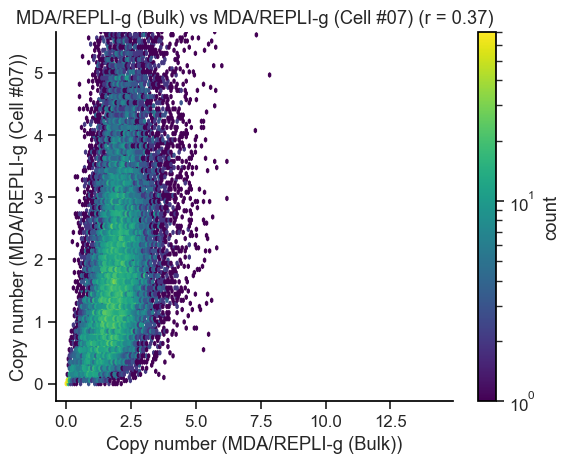

In [16]:
plot_hexbin("MDA/REPLI-g (Bulk)", "MDA/REPLI-g (Cell #07)", bcov)

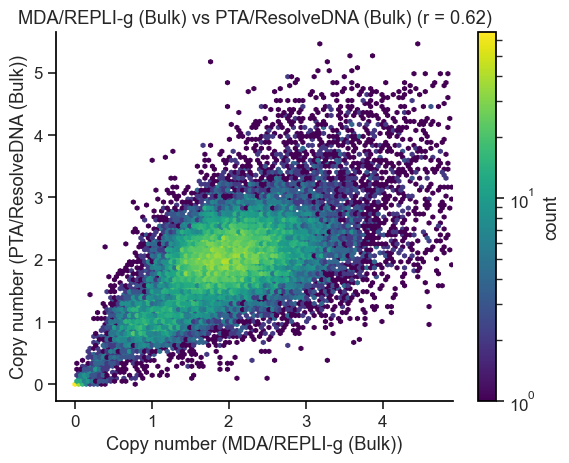

In [17]:
plot_hexbin("MDA/REPLI-g (Bulk)", "PTA/ResolveDNA (Bulk)", bcov)

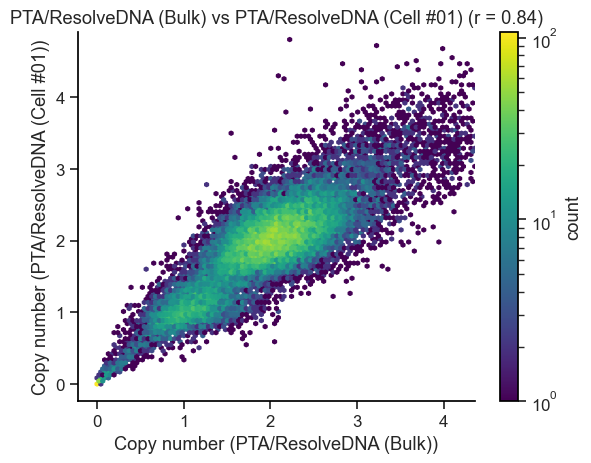

In [18]:
plot_hexbin("PTA/ResolveDNA (Bulk)", "PTA/ResolveDNA (Cell #01)", bcov)

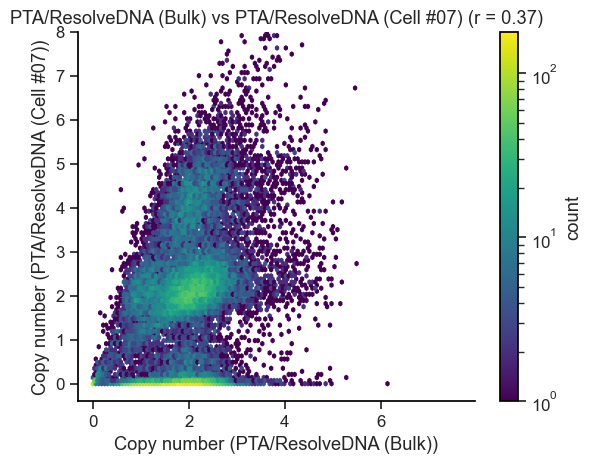

In [19]:
plot_hexbin("PTA/ResolveDNA (Bulk)", "PTA/ResolveDNA (Cell #07)", bcov, ymax=8)

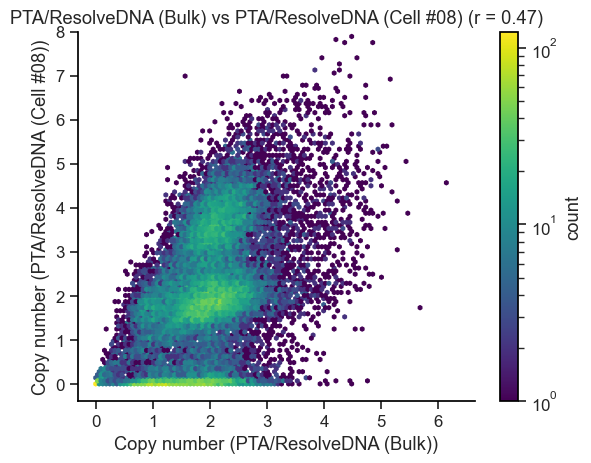

In [20]:
plot_hexbin("PTA/ResolveDNA (Bulk)", "PTA/ResolveDNA (Cell #08)", bcov, ymax=8)


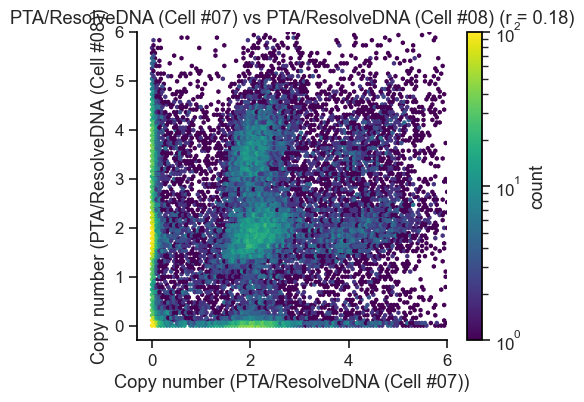

In [21]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_hexbin("PTA/ResolveDNA (Cell #07)", "PTA/ResolveDNA (Cell #08)", bcov, ax=ax, vmax=100, xmax=6, ymax=6)
fig.savefig(figdir / "coverage_hexbin_pta_cell07_cell08.svg", bbox_inches="tight")

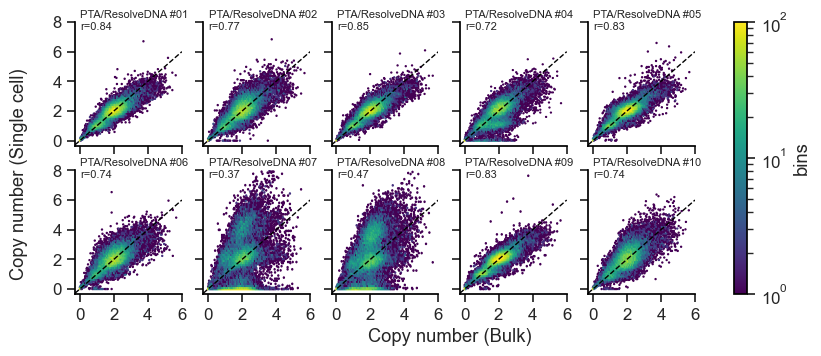

<Figure size 640x480 with 0 Axes>

In [22]:

def plot_kit_hexbins(kit, bcov, xmax=6, ymax=6):
    kit_samples = bcov.columns[bcov.columns.str.startswith(kit)]
    sc_samples = list(kit_samples[kit_samples.str.contains("Cell")])
    bulk = list(kit_samples[kit_samples.str.contains("Bulk")])
    assert len(sc_samples) == 10
    assert len(bulk) == 1
    bulk = bulk[0]

    ymax = ymax
    xmax = xmax
    height = 2
    fig, axes = plt.subplots(2, 5, figsize=(height*5, height*2), sharex=True, sharey=True)
    for ax, sample in zip(axes.flatten(), sc_samples):
        x = bulk
        y = sample

        #ymax = bcov[y].quantile(0.999)
        #xmax = bcov[x].quantile(0.999)
        xd = bcov[x]
        yd = bcov[y]
        # Normalize to median
        xd = 2 * xd / xd.median()
        yd = 2 * yd / yd.median()
        
        pearson = xd.corr(yd, method="pearson")

        mask = (xd < xmax ) & (yd < ymax)
        xd = xd[mask]
        yd = yd[mask]
        
        hb = ax.hexbin(xd, yd, gridsize=100, cmap='viridis', bins='log', mincnt=0, vmin=1, vmax=100)
        sample = sample.replace(" (Cell", "").replace(")", "").strip()
        ax.text(.05, 1.1, f"{sample}\nr={pearson:.2f}", transform=ax.transAxes, size=8, va="top",)
        
        # Set ticks at steps of 2
        xticks = np.arange(0, xmax+1, 2)
        yticks = np.arange(0, ymax+1, 2)
        ax.set_yticks(yticks)
        ax.set_xticks(xticks)

        ax.axline((0, 0), slope=1, color="black", linestyle="--", lw=1)
        ax.set_xlim(right=xmax)
        ax.set_ylim(top=ymax)

    fig.text(0.5, 0.08, 'Copy number (Bulk)', ha='center')
    fig.text(0.06, 0.5, 'Copy number (Single cell)', va='center', rotation='vertical')
    fig.subplots_adjust(bottom=0.2, hspace=0.2)
    cb = fig.colorbar(hb, ax=axes.ravel().tolist(), label='bins')
    plt.show()

plot_kit_hexbins("PTA/ResolveDNA", bcov, ymax=8)
plt.savefig(figdir / "coverage_hexbin_pta.svg", bbox_inches="tight")

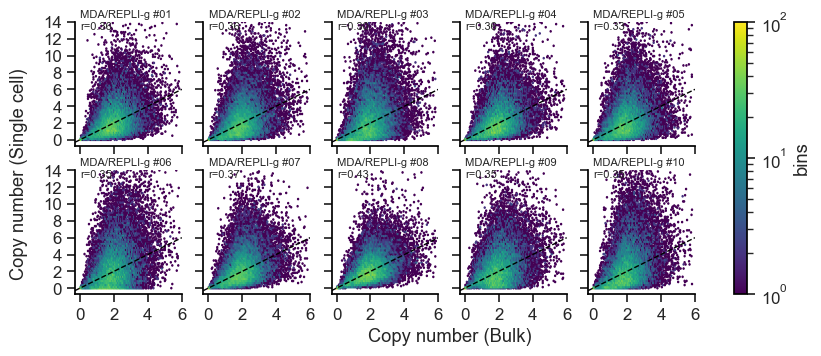

In [23]:
plot_kit_hexbins("MDA/REPLI-g", bcov, ymax=14)

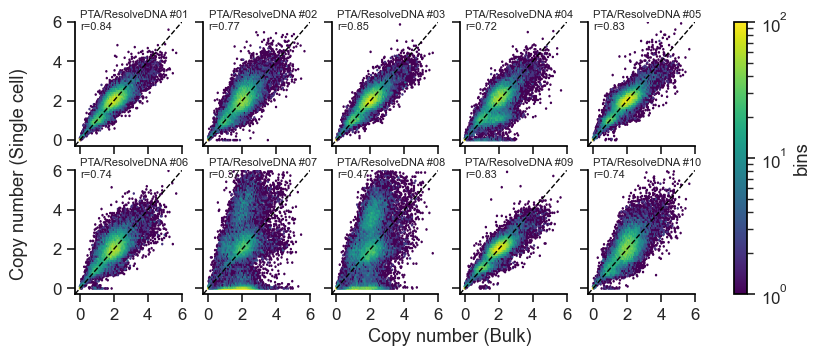

In [24]:
# Normalize by median to get approximate copy number
d = bcov.apply(lambda x: 2 * x / x.median(), axis=0)
plot_kit_hexbins("PTA/ResolveDNA", d)

### Chromosome coverage

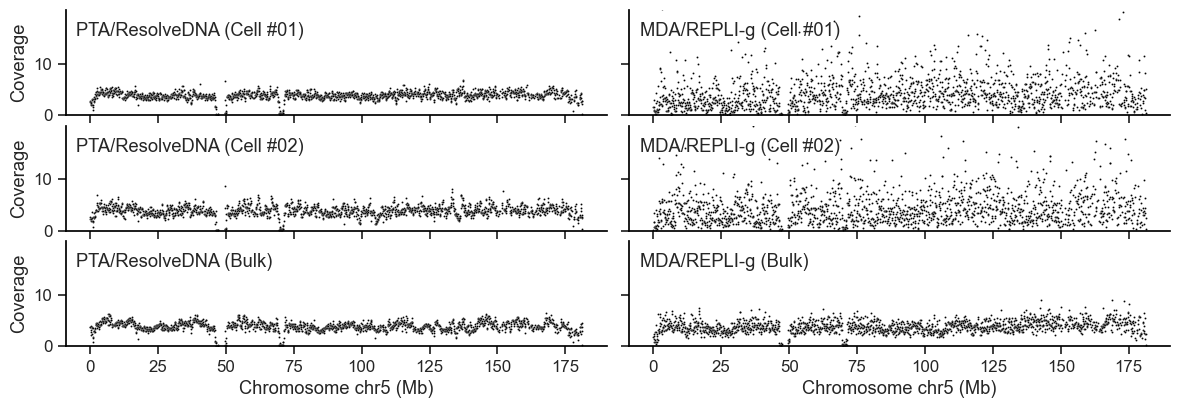

In [25]:
chromosome = "chr5"
d = bcov.query(f"contig == '{chromosome}'").copy()
d = d.melt(var_name="Sample", value_name="cov", ignore_index=False).reset_index()
show = [
    'PTA/ResolveDNA (Cell #01)',
    'MDA/REPLI-g (Cell #01)',
    'PTA/ResolveDNA (Cell #02)',
    'MDA/REPLI-g (Cell #02)',
    'PTA/ResolveDNA (Bulk)',
    'MDA/REPLI-g (Bulk)',
]
d = d[d["Sample"].isin(show)]

d["start"] = d["start"] / 1_000_000
g = sns.relplot(
    data=d, 
    x="start", 
    y="cov", 
    col="Sample",
    col_wrap=2,
    col_order=show,
    kind="scatter", 
    height=1.5, 
    aspect=4, 
    color="black",
    s=2,
    facet_kws={"sharey": True}
)
g.set(
    ylim=(0, d["cov"].quantile(0.999)), 
    ylabel="Coverage",
    xlabel=f"Chromosome {chromosome} (Mb)"
)

fig = g.figure
fig.subplots_adjust(hspace=0.1, wspace=0.04)

# Move title inside plot
for sample, ax in g.axes_dict.items():
    ax.text(0.02, 0.8, sample, transform=ax.transAxes, ha="left", va="center")
ax.set_yticks(ax.get_yticks()[:-2])
g.set_titles("")

plt.savefig(figdir / f"coverage_{chromosome}.svg", bbox_inches="tight")


## Plot coverage around CNV

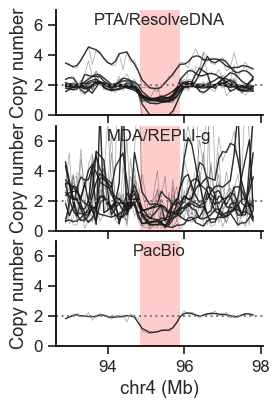

In [26]:
def plot_region(bcov, region, expand = 2, lowess_f = 100):
    # Extract region coordinates
    chromosome, start_end = region.split(":")
    start, end = start_end.split("-")
    start = int(start.replace(",", ""))
    end = int(end.replace(",", ""))
    start_cnv = start
    end_cnv = end
    
    # Expand region to show
    expand_length = (end - start) * expand
    start = max(0, start - expand_length)
    end = end + expand_length
    
    # Normalize by median to get approximate copy number
    bcov_norm = bcov.apply(lambda x: 2 * x / x.median(), axis=0)

    # Extract region
    d = bcov_norm.query(f"contig == '{chromosome}' & start >= {start} & end <= {end}").copy()

    # Melt data to long format for plotting
    d = d.melt(var_name="Sample", value_name="cov", ignore_index=False).reset_index()

    # Extract kit
    d["Kit"] = d["Sample"].apply(lambda x: x.split(" ")[0])

    # Select samples to show
    show = [
        'PTA/ResolveDNA (Cell #01)',
        'PTA/ResolveDNA (Cell #02)',
        'PTA/ResolveDNA (Cell #03)',
        'PTA/ResolveDNA (Cell #04)',
        'PTA/ResolveDNA (Cell #05)',
        'PTA/ResolveDNA (Cell #06)',
        'PTA/ResolveDNA (Cell #07)',
        'PTA/ResolveDNA (Cell #08)',
        'PTA/ResolveDNA (Cell #09)',
        'PTA/ResolveDNA (Cell #10)',
        'MDA/REPLI-g (Cell #01)',
        'MDA/REPLI-g (Cell #02)',
        'MDA/REPLI-g (Cell #03)',
        'MDA/REPLI-g (Cell #04)',
        'MDA/REPLI-g (Cell #05)',
        'MDA/REPLI-g (Cell #06)',
        'MDA/REPLI-g (Cell #07)',
        'MDA/REPLI-g (Cell #08)',
        'MDA/REPLI-g (Cell #09)',
        'MDA/REPLI-g (Cell #10)',
        'PacBio HiFi',
    ]
    d = d[d["Sample"].isin(show)]

    # Run lowess smoothing
    frac = lowess_f / d.shape[0] 
    d["smooth"] = d.groupby("Sample")["cov"].transform(lambda x: lowess(x, frac=frac))
    
    # Convert coordinates to Mb
    d["start"] = d["start"] / 1_000_000
    
    # PLOTTING
    # plot raw coverage 
    g = sns.relplot(
        data=d, 
        x="start", 
        y="cov", 
        row="Kit",
        row_order=["PTA/ResolveDNA", "MDA/REPLI-g", "PacBio"],
        units="Sample",
        estimator=None,
        #row_order=show,
        color="k",
        kind="line", 
        height=1.5, 
        aspect=2, 
        lw=0.5,
        alpha=0.4,
        legend=False,
        facet_kws={"sharey": False}
    )

    # plot lowess smoothed coverage
    g.map_dataframe(
        sns.lineplot,
        data=d, 
        x="start", 
        y="smooth", 
        color="k",
        units="Sample",
        estimator=None,
        lw=1,
        alpha=0.9
    )
    
    # Format plot
    g.set(
        ylim=(0, 7),
        ylabel="Copy number",
        xlabel=f"{chromosome} (Mb)",
        yticks=[0, 2, 4, 6],
    )
    # Plot horizontal line at 2
    g.refline(y=2, linestyle=":")
    fig = g.figure
    fig.subplots_adjust(hspace=0.1, wspace=0.04)

    # Move title inside plot and mark CNV region
    for sample, ax in g.axes_dict.items():
        ax.text(0.5, 0.9, sample, transform=ax.transAxes, ha="center", va="center", fontsize=12)
        ax.axvspan(start_cnv / 1_000_000, end_cnv / 1_000_000, color="red", lw=0, alpha=0.2, zorder=-1)

    g.set_titles("")

plot_region(bcov, "chr4:94853358-95876805")
plt.savefig(figdir / "coverage_CNV_chr4_94853358-95876805.svg", bbox_inches="tight")


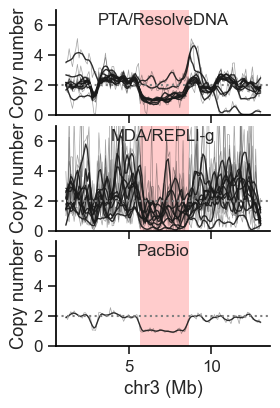

In [27]:
plot_region(bcov, "chr3:5661346-8648856", lowess_f=150, expand=1.5)
plt.savefig(figdir / "coverage_CNV_chr3_5661346-8648856.svg", bbox_inches="tight")

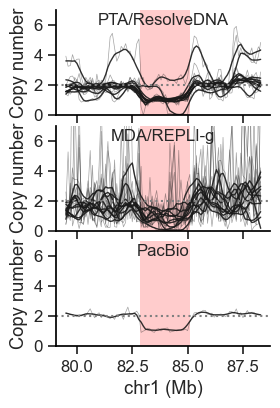

In [28]:
plot_region(bcov, "chr1:82856335-85109746", lowess_f=200, expand=1.5)
plt.savefig(figdir / "coverage_CNV_chr1_82856335-85109746.svg", bbox_inches="tight")

## Bulk deviation

In [29]:
def get_residuals(x, y):
    # Fit a linear model
    model = np.polyfit(x, y, 1)
    predict = np.polyval(model, x)
    residuals = y - predict
    return residuals

rcov = []
for i, sample in human_samples.iterrows():
    path = base_path / f"mosdepth_100kb/{sample["NGI ID"]}.regions.bed.gz"
    d = pd.read_csv(path, sep="\t", header=None, names=["contig", "start", "end", "cov"])
    d = d[d["contig"].isin(chr1toX)]
    d["Sample"] = sample["SampleName"]
    d["Kit"] = sample["Kit"]
    d["IsSingleCell"] = sample["IsSingleCell"]
    rcov.append(d)

rcov = pd.concat(rcov)
#rcov["cov"] = rcov.groupby(["Kit", "contig", "start"])["cov"].transform(lambda x: x - x.median())
rcov = rcov.pivot(index=["contig", "start", "end"], columns="Sample", values="cov")

# Map samples to bulk
sample_to_bulk = samples.set_index("SampleName", drop=False).groupby("Kit")["SampleName"].transform(lambda x: x.iloc[-1]).to_dict()

for sample in samples.query("IsSingleCell")["SampleName"]:
    bulk = sample_to_bulk[sample]
    rcov[sample] = get_residuals(rcov[bulk], rcov[sample])  

rcov = rcov.melt(value_vars=rcov.columns, var_name="Sample", value_name="cov", ignore_index=False).reset_index()
rcov["Kit"] = rcov["Sample"].map(samples.set_index("SampleName")["Kit"])
rcov["IsSingleCell"] = rcov["Sample"].map(samples.set_index("SampleName")["IsSingleCell"])

# rcov["bulk_norm_cov"] = rcov.groupby(["Kit", "contig", "start"])["cov"].transform(lambda x: x - x.iloc[-1])

def genome_position(x):
    return x["contig"].str.cat(x["start"].astype(str), sep=":")

chr_ends = dict(rcov.groupby("contig")["end"].max())
chr_offset = {}
offset = 0
for c in chr1toX:
    chr_offset[c] = offset
    offset += chr_ends[c]
rcov["pos"] = rcov["start"] + rcov["contig"].map(chr_offset)
rcov.head()

,contig,start,end,Sample,cov,Kit,IsSingleCell,pos
0,chr1,0,100000,MDA/REPLI-g (Bulk),3.07249,MDA/REPLI-g,False,0
1,chr1,100000,200000,MDA/REPLI-g (Bulk),0.97113,MDA/REPLI-g,False,100000
2,chr1,200000,300000,MDA/REPLI-g (Bulk),0.83427,MDA/REPLI-g,False,200000
3,chr1,300000,400000,MDA/REPLI-g (Bulk),0.00000,MDA/REPLI-g,False,300000
4,chr1,400000,500000,MDA/REPLI-g (Bulk),0.08888,MDA/REPLI-g,False,400000


/Users/pontus.hojer/miniconda3/envs/scwgs/lib/python3.12/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/Users/pontus.hojer/miniconda3/envs/scwgs/lib/python3.12/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


<Axes: xlabel='Sample', ylabel='Sample'>

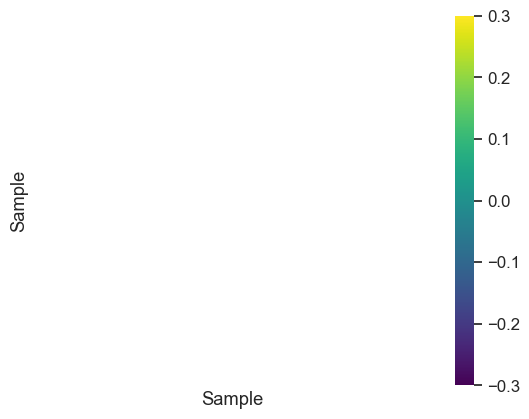

In [30]:
d = rcov.query('Kit == "BioSkryb"').pivot(index="pos", columns="Sample", values="cov")
corr = d.corr(method="pearson")
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask, k=0)] = True
corr = corr.mask(mask)
sns.heatmap(corr, cmap="viridis", center=0, vmax=0.3, vmin=-0.3)

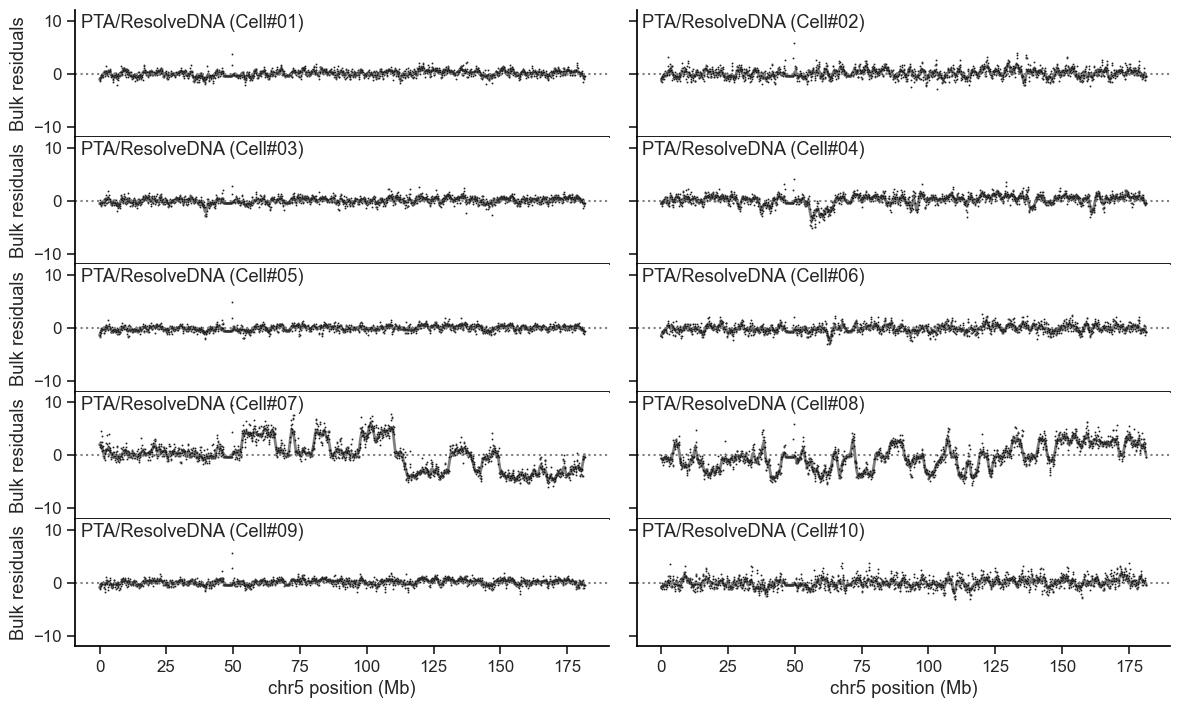

In [31]:
chromosome = "chr5"
d = rcov.query(f"Kit == 'PTA/ResolveDNA' & contig == '{chromosome}' & IsSingleCell").copy()
#d["smooth"] = d.groupby("Sample")["bulk_norm_cov"].transform(lambda x: x.rolling(20, center=True).mean())
#d["lowess"] = d.groupby("Sample")["cov"].transform(lambda x: x.rolling(50, center=True).apply(interpolate))
d["lowess"] = d.groupby("Sample")["cov"].transform(lambda x: lowess(x, frac=0.01))
d["start"] = d["start"] / 1_000_000
g = sns.relplot(
    data=d, 
    x="start", 
    y="cov", 
    col="Sample", 
    col_wrap=2, 
    color="k",
    kind="scatter", 
    height=1.5, 
    aspect=4, 
    s=2
)
g.map_dataframe(
    sns.lineplot, 
    data=d, 
    x="start", 
    y="lowess", 
    color="black", 
    legend=False, 
    alpha=0.5,
    lw=2,
)
g.set(
    #ylim=(d["cov"].quantile(0.001), d["cov"].quantile(0.999)), 
    ylim=(-12, 12),
    ylabel="Bulk residuals",
    xlabel=f"{chromosome} position (Mb)"
)
g.set_titles("{col_name}")
g.refline(y=0, linestyle=":")
fig = g.figure
fig.subplots_adjust(hspace=0)
# Move title inside plot
for ax in g.axes.ravel():
    ax.text(0.01, 0.9, ax.title.get_text(), transform=ax.transAxes, ha="left", va="center")
    ax.set_title("")

Text(0, 0.5, 'Bulk residuals')

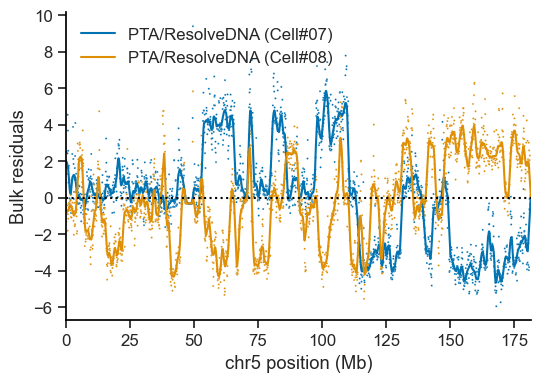

In [32]:
chromosome = "chr5"
d = rcov.query(f"Kit == 'PTA/ResolveDNA' & contig == '{chromosome}' & IsSingleCell").copy()
d = d[d["Sample"].isin(["PTA/ResolveDNA (Cell#07)", "PTA/ResolveDNA (Cell#08)"])]

# Lowess smoothing
d["lowess"] = d.groupby("Sample")["cov"].transform(lambda x: lowess(x, frac=0.01))

d["start"] = d["start"] / 1_000_000
fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.scatterplot(
    data=d, 
    x="start", 
    y="cov", 
    hue="Sample",
    s=2,
    legend=False
)
ax = sns.lineplot(
    data=d, 
    x="start", 
    y="lowess", 
    hue="Sample",
)
ax.axhline(0, color="black", linestyle=":")
ax.set_xlim(d["start"].min(), d["start"].max())
ax.set_xlabel(f"{chromosome} position (Mb)")
ax.legend(frameon=False, loc="upper left")
ax.set_ylabel("Bulk residuals")